# Short dipole analysis

The short ($L \ll \lambda/2$) dipole power in the far field for an
antenna of length $L$ is
$$P(\theta, \nu) \propto (L\nu)^2 \cos^2\theta$$
where $\theta$ is the polar angle from the antenna axis. Equivalently
$$P(\theta, \nu) \propto (L\nu)^2 \left(\tfrac{3\sqrt{5}}{2}Y_0^0(\theta) + Y_2^0(\theta)\right)$$
so the pattern lives entirely in $\ell=0$ and $\ell=2$.

We build a stack of horizon-masked dipole maps over 1–50 MHz, extract
their SVD modes, and project a Dark-Ages 21-cm template onto the
foreground basis to demonstrate mode contamination of the global signal.

In [1]:
import os
os.environ["JAX_ENABLE_X64"] = "True"

import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

from lusee.MonoSkyModels import T_DarkAges  # exposed as lusee.monosky too

The croissant.jax interface is deprecated and will be removed in a future release. Please use the croissant interface directly instead.


In [2]:
def dipole_map(frequency, ant_length=1.0, nside=16, lmax=2):
    """Far-field power of a short dipole at a single frequency."""
    mmax = lmax
    size = int(mmax * (2 * lmax + 1 - mmax) / 2 + lmax + 1)

    l_eff_sq = (ant_length * frequency) ** 2
    a00 = l_eff_sq * 3 * np.sqrt(5) / 2
    a20 = l_eff_sq

    alm = np.zeros(size, dtype=complex)
    alm[0] = a00
    alm[2] = a20

    return hp.alm2map(alm, nside)


def dipole_maps(frequencies, **kwargs):
    """Stack of dipole maps scaled as (nu/nu0)^2."""
    f0 = frequencies[0]
    ref = dipole_map(f0, **kwargs)
    return (frequencies[:, None] / f0) ** 2 * ref[None, :]

In [3]:
freq = np.linspace(1, 50, 101)
beams = dipole_maps(freq, ant_length=1.0, nside=64)

# horizon cutoff: zero out the lower hemisphere
mask = np.ones_like(beams[0])
mask[len(mask) // 2:] = 0
beams *= mask

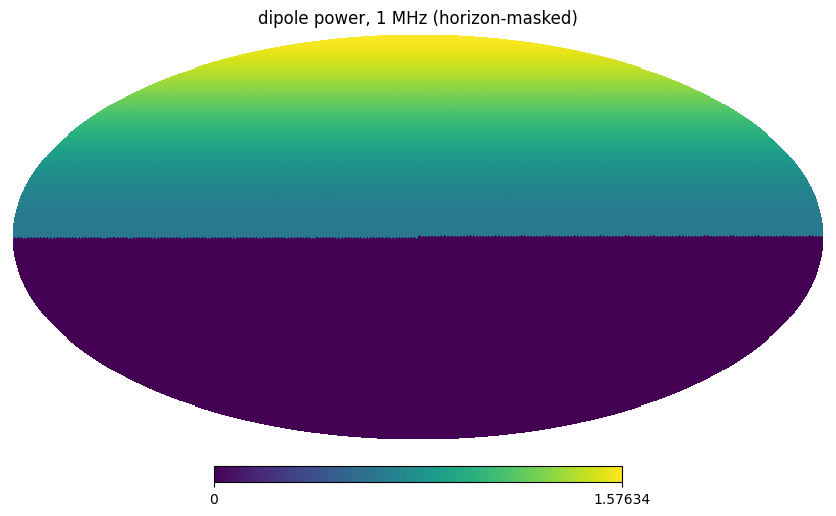

In [4]:
hp.mollview(beams[0], title="dipole power, 1 MHz (horizon-masked)")

## SVD of the foreground stack

Text(0.5, 1.0, 'Foreground covariance spectrum')

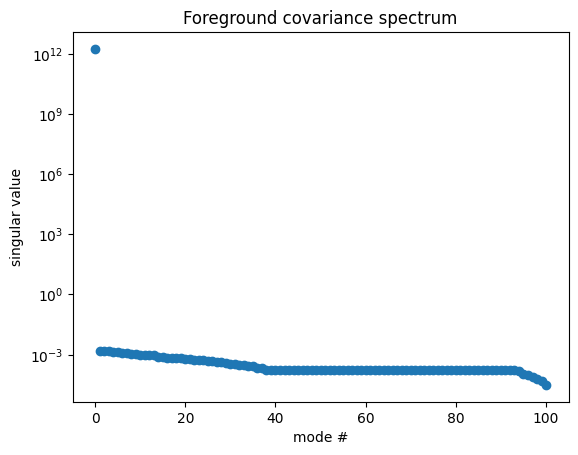

In [5]:
d = beams.T              # (npix, nfreq)
d = d - d.mean(axis=0)
C = d.T @ d
U, S, V = np.linalg.svd(C)

eig_nr = np.arange(len(S))
plt.figure()
plt.scatter(eig_nr, S)
plt.yscale("log")
plt.xlabel("mode #"); plt.ylabel("singular value")
plt.title("Foreground covariance spectrum")

Text(0.5, 1.0, 'Leading frequency-mode shape')

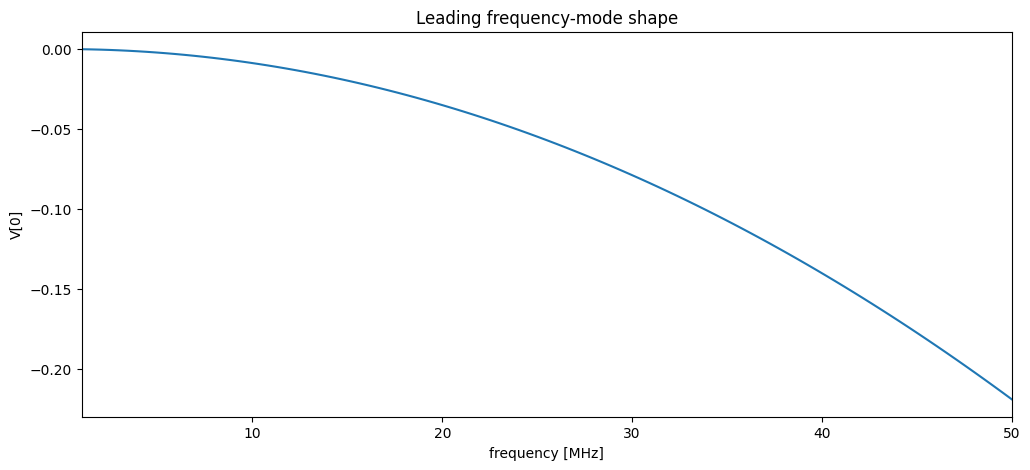

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(freq, V[0])
plt.xlim(freq.min(), freq.max())
plt.xlabel("frequency [MHz]"); plt.ylabel("V[0]")
plt.title("Leading frequency-mode shape")

## Dark-Ages global signal

(0.0, 50.0)

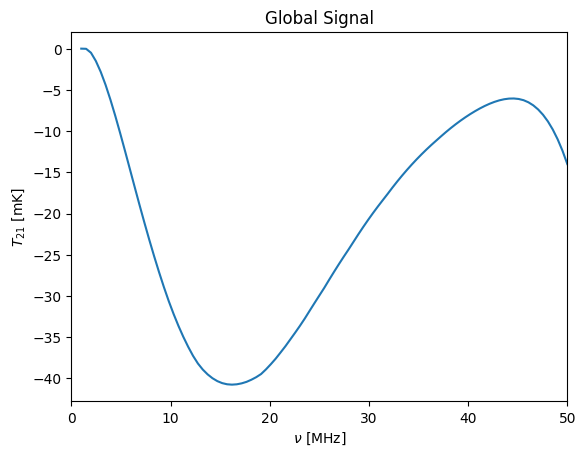

In [7]:
t21 = T_DarkAges(freq) * 1e3  # mK
plt.figure()
plt.plot(freq, t21)
plt.xlabel(r"$\nu$ [MHz]"); plt.ylabel(r"$T_{21}$ [mK]")
plt.title("Global Signal")
plt.xlim(0, freq.max())

Project the global signal onto the foreground eigenbasis: most of the
power piles up in the leading (smooth) mode.

Text(0.5, 1.0, 'Global signal in foreground eigenbasis')

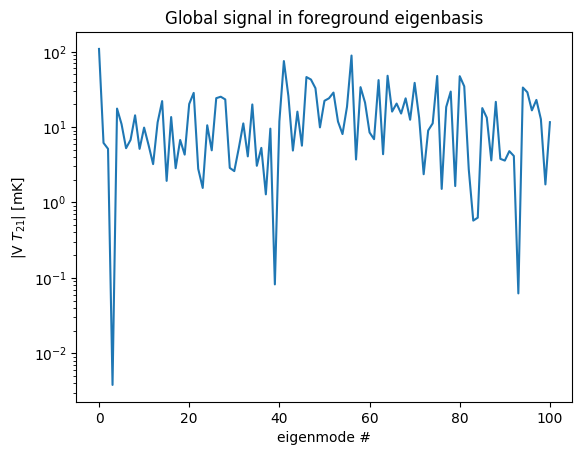

In [8]:
proj_t21 = np.abs(V @ t21)
plt.figure()
plt.plot(eig_nr, proj_t21)
plt.yscale("log")
plt.xlabel("eigenmode #"); plt.ylabel(r"|V $T_{21}$| [mK]")
plt.title("Global signal in foreground eigenbasis")

Drop the brightest foreground mode and reconstruct: the smooth global
signal collapses, since it lives almost entirely in that mode.

Text(0.5, 1.0, 'Global Signal after foreground subtraction')

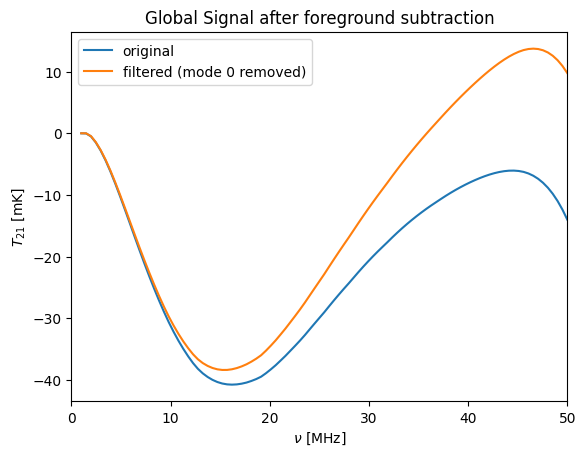

In [9]:
f21 = V @ t21
f21_filt = f21.copy(); f21_filt[0] = 0
rec_21 = np.linalg.inv(V) @ f21_filt

plt.figure()
plt.plot(freq, t21, label="original")
plt.plot(freq, rec_21, label="filtered (mode 0 removed)")
plt.xlabel(r"$\nu$ [MHz]"); plt.ylabel(r"$T_{21}$ [mK]")
plt.legend(); plt.xlim(0, freq.max())
plt.title("Global Signal after foreground subtraction")